# Validate nominal cavity visibility (Milestone 2)

This notebook runs the FINESSE-only visibility engine on reference beam states:
nominal alignment, lateral offset, angular misalignment, and waist mismatch.

**Requires FINESSE 3** (`conda install -c conda-forge finesse`) in the active kernel.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from optical_truss_ifo_sim.config import load_config, resolve_repo_paths
from optical_truss_ifo_sim.finesse_runner import (
    finesse_available,
    load_beam_states,
    run_cavity_scan,
)

REPO = Path.cwd()
if not (REPO / "pyproject.toml").is_file():
    REPO = REPO.parent

if not finesse_available():
    raise RuntimeError(
        "FINESSE 3 is not importable. Install with: conda install -c conda-forge finesse"
    )

cfg = resolve_repo_paths(
    load_config(REPO / "configs" / "finesse_validation.yaml", repo_root=REPO),
    REPO,
)
beams = load_beam_states(REPO / "tests/reference_data/beam_states_nominal.csv")
print(f"Loaded {len(beams)} beam states; detuning points = {cfg.finesse.detuning_points}")

Loaded 4 beam states; detuning points = 1001


/Users/mdovale/Work-local/optical-truss-ifo-sim/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
results = [run_cavity_scan(beam, cfg.finesse) for beam in beams]

for item in results:
    flags = ", ".join(f.value for f in item.visibility.qc_flags) or "none"
    print(
        f"{item.sample_id:14s}  V_00={item.v_00:6.4f}  status={item.status.value}  qc={flags}"
    )

/Users/mdovale/Work-local/optical-truss-ifo-sim/.venv/lib/python3.12/site-packages/finesse/model.py:2238: CavityUnstableWarning: cavity 'cav' added to the model is unstable
  warn(
/Users/mdovale/Work-local/optical-truss-ifo-sim/.venv/lib/python3.12/site-packages/finesse/model.py:4775: CavityUnstableWarning: The cavities ['cav'] are unstable and will not be used for beam tracing.
  warn(
/Users/mdovale/Work-local/optical-truss-ifo-sim/.venv/lib/python3.12/site-packages/finesse/model.py:2238: CavityUnstableWarning: cavity 'cav' added to the model is unstable
  warn(
/Users/mdovale/Work-local/optical-truss-ifo-sim/.venv/lib/python3.12/site-packages/finesse/model.py:4775: CavityUnstableWarning: The cavities ['cav'] are unstable and will not be used for beam tracing.
  warn(
/Users/mdovale/Work-local/optical-truss-ifo-sim/.venv/lib/python3.12/site-packages/finesse/model.py:2238: CavityUnstableWarning: cavity 'cav' added to the model is unstable
  warn(
/Users/mdovale/Work-local/optical-tru

nominal         V_00=0.0000  status=QC_FAILED  qc=reflected_baseline_unstable, resonance_not_found, multiple_competing_minima, reflected_baseline_unstable
offset_x        V_00=0.0000  status=QC_FAILED  qc=reflected_baseline_unstable, resonance_not_found, multiple_competing_minima, reflected_baseline_unstable
angle_x         V_00=0.0000  status=QC_FAILED  qc=reflected_baseline_unstable, resonance_not_found, multiple_competing_minima, reflected_baseline_unstable
waist_mismatch  V_00=0.0000  status=QC_FAILED  qc=reflected_baseline_unstable, resonance_not_found, multiple_competing_minima, reflected_baseline_unstable


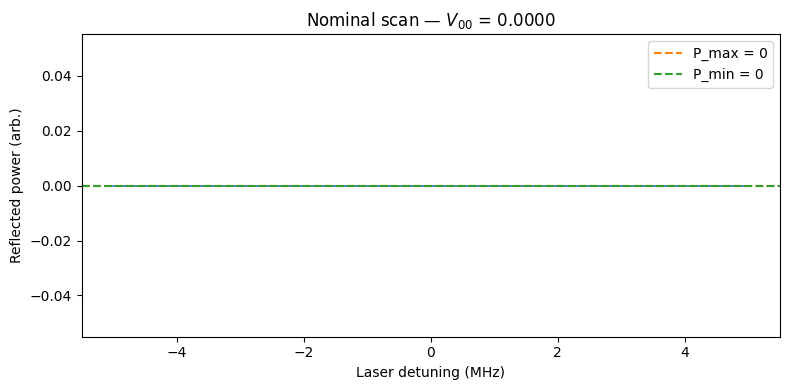

In [3]:
nominal = results[0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(nominal.detuning_hz / 1e6, nominal.reflected_power, lw=1.2)
ax.axhline(nominal.visibility.p_max, color="C1", ls="--", label=f"P_max = {nominal.visibility.p_max:.3g}")
ax.axhline(nominal.visibility.p_min, color="C2", ls="--", label=f"P_min = {nominal.visibility.p_min:.3g}")
ax.set_xlabel("Laser detuning (MHz)")
ax.set_ylabel("Reflected power (arb.)")
ax.set_title(f"Nominal scan — $V_{{00}}$ = {nominal.v_00:.4f}")
ax.legend()
fig.tight_layout()

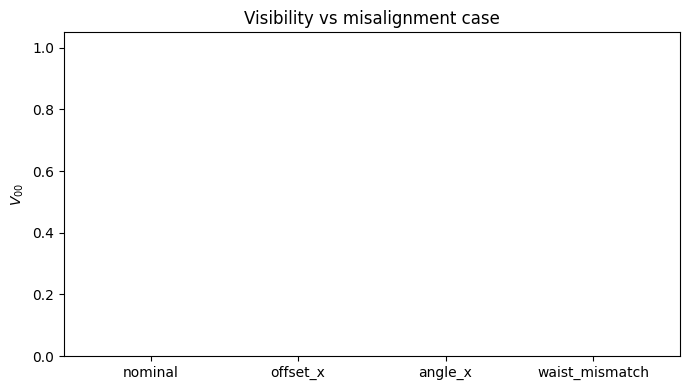

In [4]:
labels = [r.sample_id for r in results]
v_values = [r.v_00 for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, v_values, color=["C0", "C3", "C3", "C3"])
ax.set_ylabel(r"$V_{00}$")
ax.set_ylim(0, 1.05)
ax.set_title("Visibility vs misalignment case")
fig.tight_layout()

## CLI equivalent

```bash
oti-pipeline finesse-run tests/reference_data/beam_states_nominal.csv \
  configs/finesse_validation.yaml
```

See `docs/milestone-2.md` and `docs/finesse_interface.md` for details.